# Timeseries

In [1]:
from datetime import datetime
import calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
from sklearn.metrics import *

In [2]:
df = pd.read_csv('CleanData_PM10.csv')
print(df.info())
df.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  292 non-null    object 
 1   PM10      292 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.7+ KB
None


,datetime,PM10
0,2020-01-01 00:00:00,42.0
1,2020-01-02 00:00:00,39.0


In [3]:
# conversione del dato numerico
#df['datetime'] = pd.to_datetime(df['datetime']) # automatically recognize format
df['datetime'] = pd.to_datetime(df['datetime'], format = '%Y-%m-%d %H:%M:%S')

In [4]:
print(df.info())
df.head(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  292 non-null    datetime64[ns]
 1   PM10      292 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.7 KB
None


,datetime,PM10
0,2020-01-01,42.0
1,2020-01-02,39.0


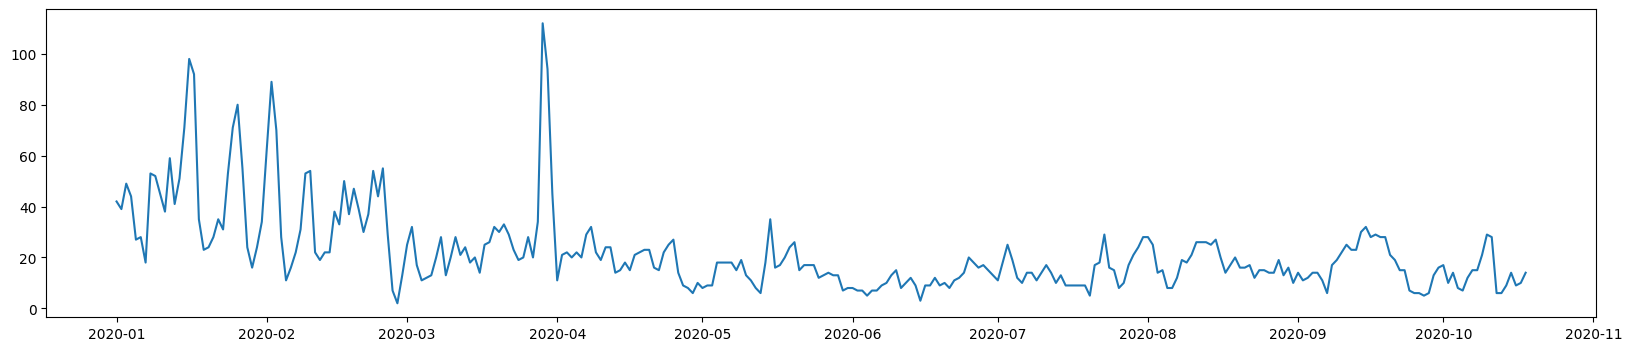

In [5]:
plt.figure(figsize = (20, 4))
plt.plot(df['datetime'], df['PM10'])
plt.show()

## Features

In [6]:
# features based on time

df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].apply(lambda t: calendar.day_name[t.weekday()])
df['weekend01'] = df['weekday'].apply(lambda w: 1  if (w == 'Saturday' or w == 'Sunday') else 0)
df.head(2)

,datetime,PM10,month,weekday,weekend01
0,2020-01-01,42.0,1,Wednesday,0
1,2020-01-02,39.0,1,Thursday,0


In [7]:
# features based on lag
df['PM10-1'] = df['PM10'].shift(1)
df['PM10-2'] = df['PM10'].shift(2)
df['PM10-3'] = df['PM10'].shift(3)
df.head(5)

,datetime,PM10,month,weekday,weekend01,PM10-1,PM10-2,PM10-3
0,2020-01-01,42.0,1,Wednesday,0,NaN,NaN,NaN
1,2020-01-02,39.0,1,Thursday,0,42.0,NaN,NaN
2,2020-01-03,49.0,1,Friday,0,39.0,42.0,NaN
3,2020-01-04,44.0,1,Saturday,1,49.0,39.0,42.0
4,2020-01-05,27.0,1,Sunday,1,44.0,49.0,39.0


In [8]:
# fix NaN based on initial shifts
# either remove initial columns
df = df.iloc[3:,:]
# or bfill
#df = df.bfill()
df.head()

,datetime,PM10,month,weekday,weekend01,PM10-1,PM10-2,PM10-3
3,2020-01-04,44.0,1,Saturday,1,49.0,39.0,42.0
4,2020-01-05,27.0,1,Sunday,1,44.0,49.0,39.0
5,2020-01-06,28.0,1,Monday,0,27.0,44.0,49.0
6,2020-01-07,18.0,1,Tuesday,0,28.0,27.0,44.0
7,2020-01-08,53.0,1,Wednesday,0,18.0,28.0,27.0


## Forecasting as a Regression Problem

In [23]:
print('min time', df['datetime'].min())
print('max time', df['datetime'].max())
print(df.shape)

min time 2020-01-04 00:00:00
max time 2020-10-18 00:00:00
(289, 11)


In [9]:
# split between train and test
tt_split = datetime.strptime('2020-05-02 00:00:00','%Y-%m-%d %H:%M:%S')
train = df[df['datetime'] <= tt_split]
test = df[df['datetime'] > tt_split]
train.head(4)

,datetime,PM10,month,weekday,weekend01,PM10-1,PM10-2,PM10-3
3,2020-01-04,44.0,1,Saturday,1,49.0,39.0,42.0
4,2020-01-05,27.0,1,Sunday,1,44.0,49.0,39.0
5,2020-01-06,28.0,1,Monday,0,27.0,44.0,49.0
6,2020-01-07,18.0,1,Tuesday,0,28.0,27.0,44.0


# Linear models on lags, a.k.a. autoregression (AR model)

In [14]:
from sklearn.linear_model import LinearRegression


model = LinearRegression()
model.fit(train.loc[:,['PM10-1','PM10-2','PM10-3','weekend01']], train['PM10'])

# uso joblib to save the model
import joblib
joblib.dump(model, 'model_PM10.pkl')



['model_PM10.pkl']

In [15]:
# leggo il modello dal file
model = joblib.load('model_PM10.pkl')

In [ ]:

yp_train = model.predict(train.loc[:,['PM10-1','PM10-2','PM10-3','weekend01']])
yp = model.predict(test.loc[:,['PM10-1','PM10-2','PM10-3','weekend01']])
yp2 = test['PM10-1']  # naive forecast

# note. This is not a pure AR model beccause of the 'weekend01' covariate


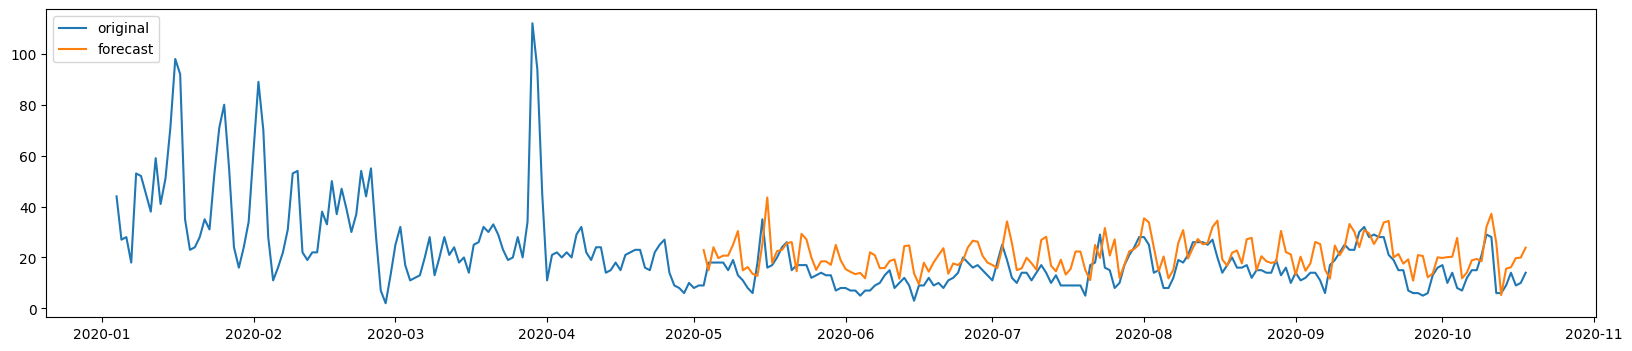

In [12]:
plt.figure(figsize = (20, 4))
plt.plot(df['datetime'],df['PM10'],label='original')
plt.plot(test['datetime'],yp,label='forecast')
#plt.plot(test['datetime'],yp2,label='naive forecast')
plt.legend(loc="upper left")
plt.show()

In [25]:
print('MAE = ',mean_absolute_error(test['PM10'],yp))
print('MAE = ',mean_absolute_error(test['PM10'],yp2))

MAE =  6.784168473816068
MAE =  3.42603550295858


In [26]:
print(['PM10-1','PM10-2','PM10-3','weekend01'])
print(model.coef_)

['PM10-1', 'PM10-2', 'PM10-3', 'weekend01']
[ 0.99401746 -0.4747933   0.1074839   7.25337159]


c:\Users\marco\Dropbox\Code\PYTHON\PCLOUD26\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\marco\Dropbox\Code\PYTHON\PCLOUD26\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\marco\Dropbox\Code\PYTHON\PCLOUD26\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\marco\Dropbox\Code\PYTHON\PCLOUD26\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\marco\Dropbox\Code\PYTHON\PCLOUD26\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not

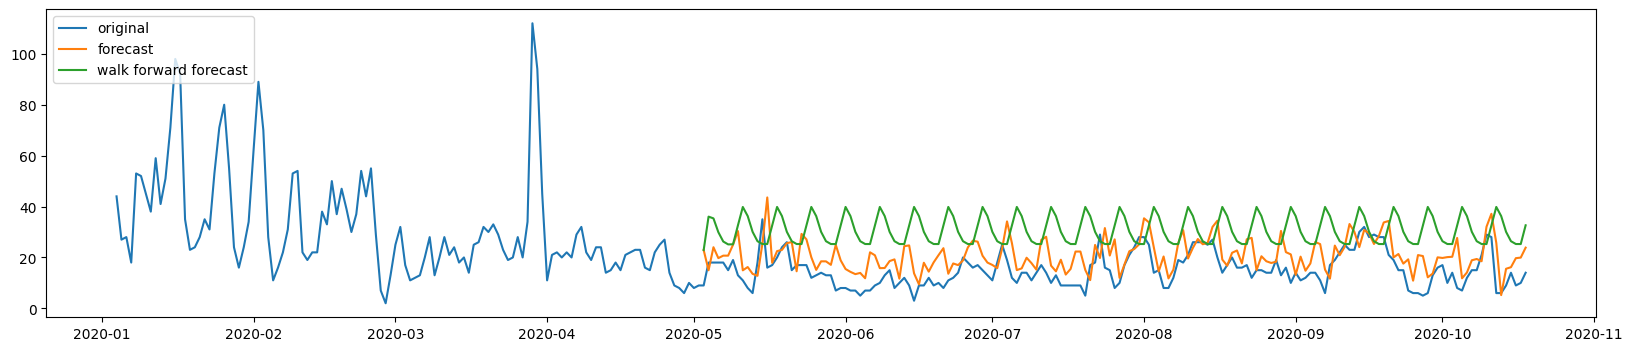

In [13]:
# walk forward predictions, forecast multiple step in advance

last = train.iloc[-1,:]

history = [last['PM10'],last['PM10-1'],last['PM10-2'],last['weekend01']]

#model.predict([history])
predictions =[model.predict([history])[0]]

for t in range(len(test)-1):
    history[2] = history[1]
    history[1] = history[0]
    history[0] = predictions[-1]
    history[3] = test.iloc[t,:]['weekend01']
    predictions.append(model.predict([history])[0])


    
plt.figure(figsize = (20, 4))
plt.plot(df['datetime'],df['PM10'],label='original')
plt.plot(test['datetime'],yp,label='forecast')
plt.plot(test['datetime'],predictions,label='walk forward forecast')
plt.legend(loc="upper left")
plt.show()